In [17]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from preprocessing.ecg_preprocessor import ECGPreprocessor
from optimization.fmm_optimizer import FMMOptimizer
from vcg.visualizer import VCGVisualizer
from vcg.calculator import VCGCalculator


In [19]:
test_ecg_path = "~/UNI/CORSI/Visione_Artificiale/progetto/datasets/PTB/s0001_re.csv"
lead_names = ["i","ii","iii","avl","avr","avf","v1","v2","v3","v4","v5","v6"]
df = pd.read_csv(test_ecg_path)[lead_names]
# shape = (n_leads, n_samples)
data_in = df.to_numpy().T

In [20]:
# PREPROCESSING

sr = 500
preprocessor = ECGPreprocessor(sr)
results_post_filters, m_detrend, error_preprocessing = preprocessor.run(data_in)
results_post_filters

array([{'loessRPeaksEnd': array([  302.,  1127.,  1922.,  2727.,  3540.,  4397.,  5246.,  6064.,
               6921.,  7777.,  8602.,  9440., 10272., 11111., 11925., 12756.,
              13581., 14404., 15215., 16041., 16865., 17691., 18504., 19335.,
              20169., 21007., 21836., 22679., 23501., 24320., 25142., 25977.,
              26795., 27605., 28422., 29260., 30093., 30903., 31714., 32558.,
              33396., 34206., 35037., 35865., 36689., 37503.]), 'loessSegEnd': array([[    0,   797],
              [  798,  1604],
              [ 1605,  2405],
              [ 2406,  3215],
              [ 3216,  4055],
              [ 4056,  4907],
              [ 4908,  5737],
              [ 5738,  6579],
              [ 6580,  7435],
              [ 7436,  8272],
              [ 8273,  9105],
              [ 9106,  9940],
              [ 9941, 10776],
              [10777, 11600],
              [11601, 12424],
              [12425, 13251],
              [13252, 14075],
         

In [21]:
# estrazione del primo battito

beat_idx = 0
beat_start_idx = int(results_post_filters[0]['loessSegEnd'][beat_idx, 0])
beat_end_idx = int(results_post_filters[0]['loessSegEnd'][beat_idx, 1])

v_data_matrix_beat = m_detrend[:, beat_start_idx:beat_end_idx].T
annotation_R = int(results_post_filters[0]['loessRPeaksEnd'][beat_idx])
n_obs = v_data_matrix_beat.shape[0]

v_data_matrix_beat[0]

array([-0.07996017, -0.04532229,  0.03463657, -0.05755077,  0.06289142,
       -0.00535596,  0.02838667, -0.01017926, -0.01859679, -0.04875561,
       -0.04742871, -0.02670766])

In [22]:
# OTTIMIZZAZIONE
# derivazioni considerate: [I, II, V1, V2, V3, V4, V5, V6] 

n_waves = 5
optimizer = FMMOptimizer(n_waves=n_waves, max_iter=10)

print(f"Backfitting sul battito {beat_idx}")


params_per_lead, fitted_waves = optimizer.fit(
    ecg_data=v_data_matrix_beat, 
    annotation=annotation_R,
)


Backfitting sul battito 0


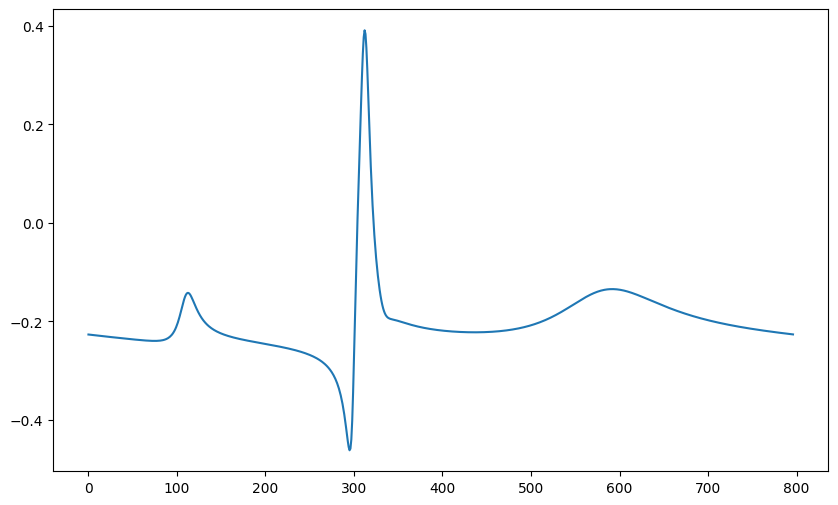

,P,Q,R,S,T
M,0.2139,0.2139,0.2139,0.2139,0.2139
A,0.0516,0.1871,0.2861,0.0232,0.0516
Alpha,4.0138,5.5050,5.6095,5.7728,1.4097
Beta,2.6527,0.8795,3.1000,6.2640,2.6845
Omega,0.0457,0.0238,0.0287,0.0456,0.2823
Var,0.0269,0.0977,0.5923,0.0290,0.1386


In [23]:
# params_per_lead sarà una lista di n_leads (8) elementi, contenente per ogni derivazione
# i valori dei vari parametri per le 5 onde

# fitted_waves è la matrice (n_samples, n_leads, n_waves) in cui le colonne fanno riferimento alle 
# derivazioni. Per ogni derivazione e per ogni istante temporale, abbiamo un vettore di 5 elementi con 
# i valori delle 5 onde. Da modello, per ottenere il valore di quel campione per l'onda ricostruita, 
# basta sommare i valori delle 5 onde

# es. per prima derivazione
lead = 1

first_lead_fitted = fitted_waves[:,lead,:]

reconstructed_lead = []
for waves in first_lead_fitted: reconstructed_lead.append(sum(waves))

plt.figure(figsize=(10, 6))
plt.plot(reconstructed_lead)
plt.show()

df = pd.DataFrame(params_per_lead[lead]).T
df.columns = ['P', 'Q', 'R', 'S', 'T']
df = df.round(4)
df


Proiezione Coordinate Nello Spazio e Generazione Assi Geometrici VCG...

Renderizzazione Modello VCG 3D Decomposto:


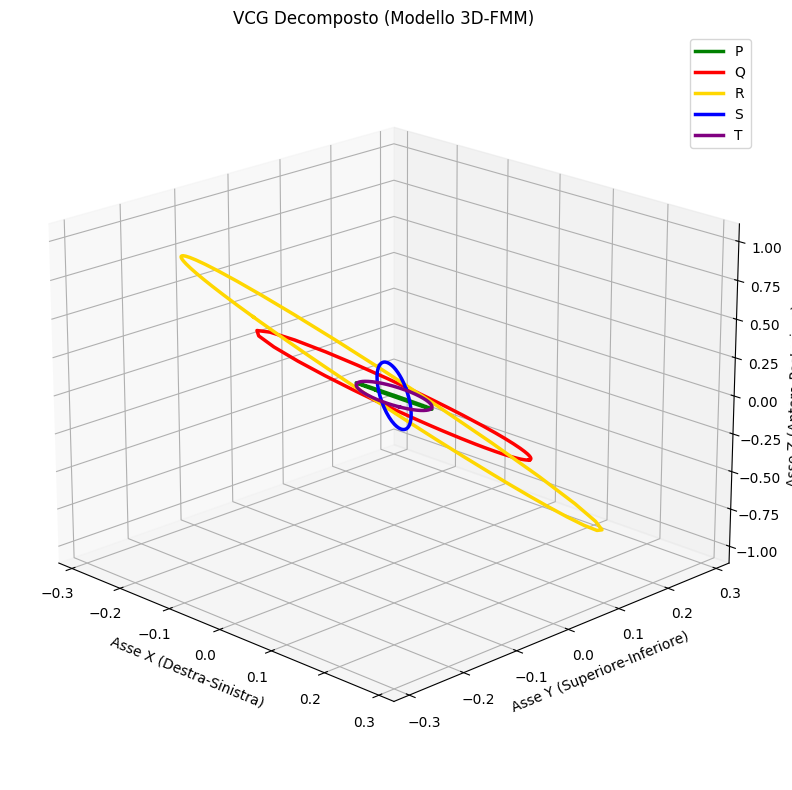

Renderizzazione Modello Diagnostici VCG 2D:


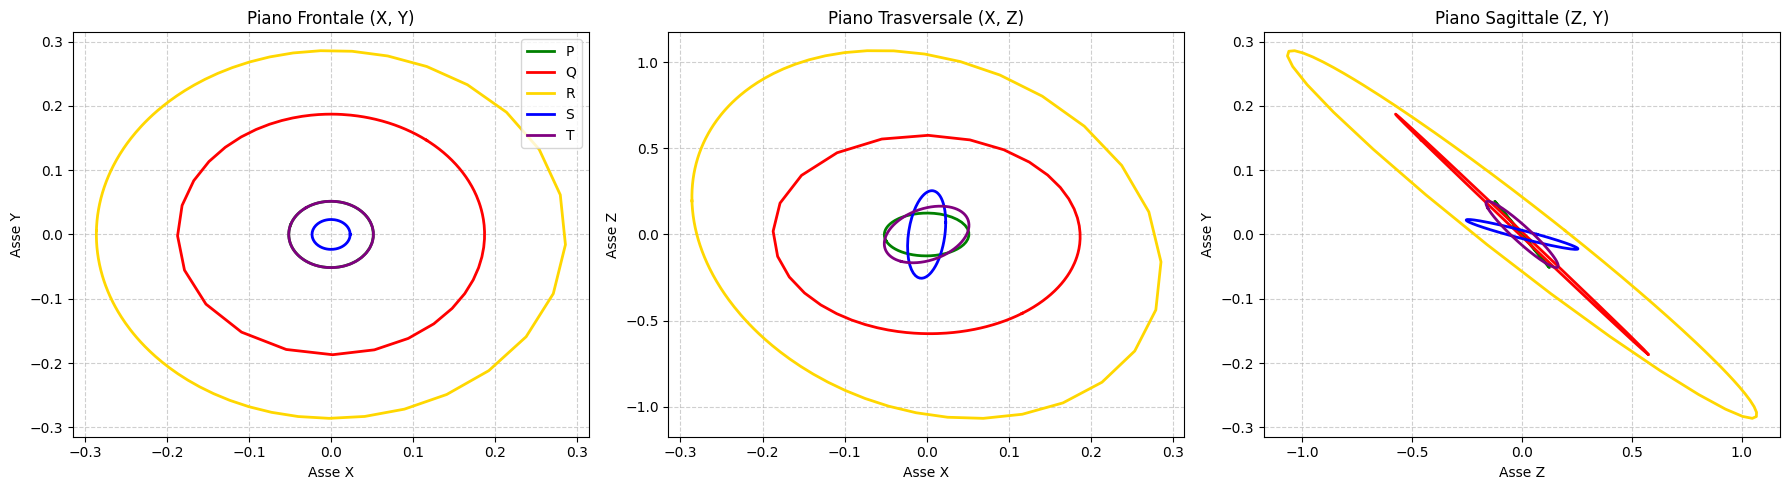

In [ ]:
# VCG

# derivazioni considerate: [I, II, V1, V2, V3, V4, V5, V6] 
params_lead_II = params_per_lead[1]
params_lead_V2 = params_per_lead[3]
time_points = FMMOptimizer.generate_time_points(n_obs)

print("Proiezione Coordinate Nello Spazio e Generazione Assi Geometrici VCG...")
# Estrae matrice dizionario separata per onde
vcg_calculator = VCGCalculator(params_lead_II, params_lead_V2, time_points)
vcg_waves_data = vcg_calculator.calculate_axes()

# animazioni
vcg_visualizer = VCGVisualizer(vcg_waves_data, labels=['P', 'Q', 'R', 'S', 'T'])
vcg_visualizer.animate_3d()

In [ ]:
vcg_visualizer.animate_2d_planes()